# Instrumental Variables

## Part 1 — IV example on mock dataset

### Constructing the dataset

We create four random series of length $N=100000$:

- $x$: education
- $y$: salary
- $z$: ambition (confounding factor)
- $q$: early smoking (candidate instrument)

The relationships are:

1. $x$ and $z$ cause $y$
2. $z$ causes $x$
3. $q$ is correlated with $x$, but **not** with $z$

A problem arises when the confounding factor $z$ is not observed. In that case, we can try to estimate the direct effect of $x$ on $y$ by using $q$ as an **instrument**.

Run the cells below to create the mock dataset.

In [2]:
import numpy as np
import pandas as pd

In [3]:
N = 100000
ϵ_z = np.random.randn(N)*0.1
ϵ_x = np.random.randn(N)*0.1
ϵ_q = np.random.randn(N)*0.01
ϵ_y = np.random.randn(N)*0.01

In [4]:
z = 0.1 + ϵ_z
q = 0.5 + 0.1234*ϵ_x + ϵ_q
# q affects x (so q is correlated with x)
x = 0.1 + z + q + ϵ_x
# The true model: y depends on x (coef 0.9) and z (coef 0.4)
y = 1.0 + 0.9*x + 0.4*z + ϵ_y

In [5]:
df = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "q": q
})

### Exploring the data

**Exercise 1:** Display the first rows, summary statistics, and the correlation matrix of the dataframe.

In [6]:
# TODO: show the first rows
df.head()

,x,y,z,q
0,0.684008,1.703146,0.200228,0.486037
1,0.628951,1.619036,0.109778,0.486557
2,0.769925,1.714513,0.032053,0.513845
3,0.608792,1.603413,0.151462,0.478716
4,0.689937,1.648845,0.081938,0.489621


In [8]:
# TODO: summary statistics
df.describe()

,x,y,z,q
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.700234,1.670161,0.099955,0.500085
std,0.150098,0.164525,0.099687,0.015835
min,0.071084,0.984627,-0.316059,0.427572
25%,0.599080,1.559439,0.032510,0.489455
50%,0.699997,1.670211,0.099972,0.500106
75%,0.801213,1.781082,0.167177,0.510731
max,1.358718,2.355843,0.525829,0.572536


In [9]:
# TODO: correlation matrix
df.corr()

,x,y,z,q
x,1.000000,0.981476,0.662554,0.619828
y,0.981476,1.000000,0.786414,0.508434
z,0.662554,0.786414,1.000000,-0.001381
q,0.619828,0.508434,-0.001381,1.000000


**Question:** Look at the correlation table. For $q$ to be a valid instrument we need:
- `cor(q, x)` non-zero → **relevance** (the instrument predicts $x$)
- `cor(q, z)` close to zero → **exogeneity** (the instrument does not affect $y$ through $z$)

Are these conditions satisfied?

> *Your answer here*

### OLS Regression

We use `linearmodels` to run regressions. The API is slightly different from `statsmodels`:
- `OLS.from_formula("y ~ x", df)` to define the model
- `.fit()` to estimate
- display the result directly (no `.summary()` needed)

In [10]:
from linearmodels import OLS, IV2SLS

**Exercise 2:** Regress $y$ on $x$ using OLS. What coefficient do you get on $x$?

Remember: the true model is `y = 1.0 + 0.9*x + 0.4*z`. So the true coefficient on $x$ is **0.9**.

In [11]:
# TODO: run OLS regression of y on x
model = OLS.from_formula("y ~ x", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:                      y   R-squared:                      0.9633
Estimator:                        OLS   Adj. R-squared:                 0.9633
No. Observations:              100000   F-statistic:                 2.632e+06
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:43:17   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      0.9168     0.0005     1928.0     0.0000      0.9159      0.9178
x              1.0758     0.0007     1622.5     0.00

**Question:** The coefficient on $x$ is **not** 0.9. Why?

*Hint:* $z$ (ambition) affects both $x$ and $y$ but is missing from the regression. This is called **omitted variable bias**.

> *Your answer here*

**Exercise 3:** Now assume $z$ is known. Add it to the regression: `y ~ x + z`. What happens to the coefficient on $x$?

In [12]:
# TODO: regress y on x and z

model = OLS.from_formula("y ~ x + z", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:                      y   R-squared:                      0.9963
Estimator:                        OLS   Adj. R-squared:                 0.9963
No. Observations:              100000   F-statistic:                  2.71e+07
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:43:49   Distribution:                  chi2(2)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      1.0002     0.0002     5744.6     0.0000      0.9999      1.0005
x              0.8996     0.0003     3210.5     0.00

**Expected result:** The coefficient on $x$ should now be ≈ 0.9 and the coefficient on $z$ ≈ 0.4 — matching the true model.

But in practice, we often **cannot observe** $z$. That is why we need instrumental variables.

### Instrumental variable regression

We now pretend $z$ is unobserved. We use $q$ as an instrument.

**Why does this work?** $q$ is correlated with $x$ (relevance) but not with $z$ (exogeneity). It gives us variation in $x$ that is "clean" — not contaminated by $z$.

**Exercise 4:** Run an IV regression using `IV2SLS`.

The syntax for instrumenting $x$ with $q$ is:
```python
"y ~ 1 + [x ~ q]"
```
where `[x ~ q]` means "instrument $x$ with $q$".

In [13]:
# TODO: run IV2SLS regression
formula = "y ~ 1 + [x ~ q]"
mod = IV2SLS.from_formula(formula, df)
res = mod.fit()
print(res)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                      y   R-squared:                      0.9373
Estimator:                    IV-2SLS   Adj. R-squared:                 0.9373
No. Observations:              100000   F-statistic:                 4.142e+05
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:44:25   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      1.0406     0.0010     1054.1     0.0000      1.0386      1.0425
x              0.8991     0.0014     643.62     0.00

**Question:** What is the IV estimate of the coefficient on $x$? Does it match the true value (0.9)?

This is powerful: we recovered the correct causal effect **without** observing $z$.

> *Your answer here*

---

## Part 2 — Return on Education

We follow the excellent R [tutorial](https://www.econometrics-with-r.org/12-6-exercises-10.html) from the *Econometrics with R* book.

**Goal:** measure the effect of schooling on earnings, while correcting the endogeneity bias by using distance to college as an instrument.

See _Card, David. "Using geographic variation in college proximity to estimate the return to schooling." (1993)._

### Loading the data

We download the CollegeDistance dataset from `statsmodels`.

In [14]:
import statsmodels.api as sm
ds = sm.datasets.get_rdataset("CollegeDistance", "AER")

In [15]:
# Documentation of the dataset
print(ds.__doc__[:1500])

.. container::

   .. container::

      =============== ===============
      CollegeDistance R Documentation
      =============== ===============

      .. rubric:: College Distance Data
         :name: college-distance-data

      .. rubric:: Description
         :name: description

      Cross-section data from the High School and Beyond survey
      conducted by the Department of Education in 1980, with a follow-up
      in 1986. The survey included students from approximately 1,100
      high schools.

      .. rubric:: Usage
         :name: usage

      .. code:: R

         data("CollegeDistance")

      .. rubric:: Format
         :name: format

      A data frame containing 4,739 observations on 14 variables.

      gender
         factor indicating gender.

      ethnicity
         factor indicating ethnicity (African-American, Hispanic or
         other).

      score
         base year composite test score. These are achievement tests
         given to high school seniors

In [16]:
df = ds.data  # extract the dataframe

**Exercise 5:** Explore the dataframe: show the first rows, the shape, and summary statistics.

In [17]:
# TODO: 
df.head()

,gender,ethnicity,score,fcollege,mcollege,home,urban,unemp,wage,distance,tuition,education,income,region
rownames,,,,,,,,,,,,,,
1,male,other,39.150002,yes,no,yes,yes,6.2,8.09,0.2,0.88915,12,high,other
2,female,other,48.869999,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
3,male,other,48.740002,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
4,male,afam,40.400002,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
5,female,other,40.480000,no,no,no,yes,5.6,8.09,0.4,0.88915,13,low,other


In [19]:
# TODO: print shape and describe

print(df.shape)
df.describe()

(4739, 14)


,score,unemp,wage,distance,tuition,education
count,4739.000000,4739.000000,4739.000000,4739.000000,4739.000000,4739.000000
mean,50.889029,7.597215,9.500506,1.802870,0.814608,13.807765
std,8.701910,2.763581,1.343067,2.297128,0.339504,1.789107
min,28.950001,1.400000,6.590000,0.000000,0.257510,12.000000
25%,43.924999,5.900000,8.850000,0.400000,0.484990,12.000000
50%,51.189999,7.100000,9.680000,1.000000,0.824480,13.000000
75%,57.769999,8.900000,10.150000,2.500000,1.127020,16.000000
max,72.809998,24.900000,12.960000,20.000000,1.404160,18.000000


### Creating a binary income variable

The `income` column contains text values (`"high"` or `"low"`). We need a numeric version to use in regressions.

In [20]:
# Check the unique values
df['income'].unique()

array(['high', 'low'], dtype=object)

**Exercise 6:** Create a new column `income_binary` that equals 1 if income is `"high"` and 0 otherwise.

*Hint:* `(df['income'] == 'high') * 1.0` converts True/False to 1.0/0.0.

In [21]:
# TODO: create income_binary

df['income_binary'] = (df['income'] == 'high') * 1.0

In [22]:
# Verify: should show counts for 0.0 and 1.0
df['income_binary'].value_counts()

income_binary
0.0    3374
1.0    1365
Name: count, dtype: int64

### Histogram of distance to college

**Exercise 7:** Plot a histogram of the `distance` variable. This is the variable we will use as an instrument later.

In [23]:
from matplotlib import pyplot as plt
import seaborn as sns

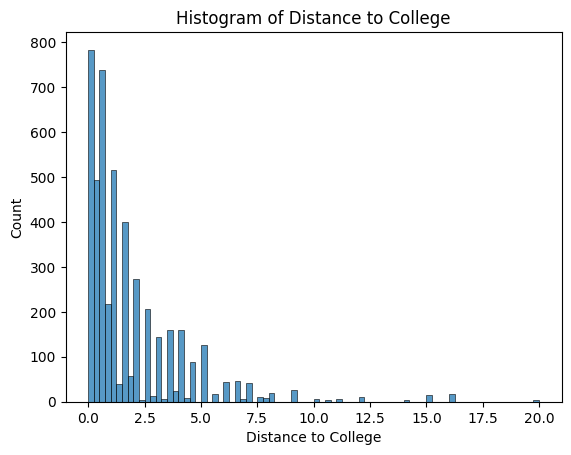

In [27]:
# TODO: plot a histogram of df['distance']
# Hint: sns.histplot(df['distance']) or plt.hist(df['distance'])
# Add labels and a title

sns.histplot(df['distance'])
plt.xlabel('Distance to College')
plt.title('Histogram of Distance to College')
plt.show()

### Naive OLS regression

We now run $\text{income\_binary} = \beta_0 + \beta_1 \cdot \text{education} + u$.

This is "naive" because education might be **endogenous** — unobserved factors (like ability or motivation) could affect both education and income.

**Exercise 8:** Run the naive regression using `IV2SLS` (it works for OLS too — just don't instrument anything).

*Hint:* `"income_binary ~ 1 + education"`

In [33]:
from linearmodels import IV2SLS

# TODO: run the naive regression

model = OLS.from_formula("income_binary ~  1 + education", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0480
Estimator:                        OLS   Adj. R-squared:                 0.0478
No. Observations:                4739   F-statistic:                    227.43
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:55:38   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -0.4780     0.0499    -9.5702     0.0000     -0.5759     -0.3801
education      0.0555     0.0037     15.081     0.00

**Question:** Is the coefficient on education significant? What is the R²? Does education explain a lot of the variation in income?

> *Your answer here*

### Adding control variables

**Exercise 9:** Augment the regression with `gender`, `ethnicity`, `urban`, and `unemp`.

Categorical variables (like `gender`, `ethnicity`) are automatically encoded as dummy variables.

In [34]:
# Check available columns
df.columns

Index(['gender', 'ethnicity', 'score', 'fcollege', 'mcollege', 'home', 'urban',
       'unemp', 'wage', 'distance', 'tuition', 'education', 'income', 'region',
       'income_binary'],
      dtype='object')

In [35]:
# TODO: run regression with education + gender + ethnicity + urban + unemp

model = OLS.from_formula("income_binary ~  1 + education + gender + ethnicity + urban + unemp", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0830
Estimator:                        OLS   Adj. R-squared:                 0.0818
No. Observations:                4739   F-statistic:                    456.93
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:56:17   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
Intercept                -0.4159     0.0538    -7.7362     0.0000     -0.5212     -0.3105
educatio

**Exercise 10:** Check which values `ethnicity` takes. Then change the reference category to `'other'` using the `C()` syntax.

*Hint:* replace `ethnicity` in the formula with `C(ethnicity, Treatment(reference='other'))`.

In [ ]:
df['ethnicity'].unique()

In [36]:
# TODO: same regression but with C(ethnicity, Treatment(reference='other'))

model = OLS.from_formula("income_binary ~  1 + education + gender + C(ethnicity, Treatment(reference='other')) + urban + unemp", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0830
Estimator:                        OLS   Adj. R-squared:                 0.0818
No. Observations:                4739   F-statistic:                    456.93
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:59:23   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                                   Parameter Estimates                                                    
                                                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------------------------------------

**Question:** Did the coefficient on education change much after adding controls? Is the model fit (Adj. R²) better?

> *Your answer here*

### The endogeneity problem

Even though the coefficient on education is significant, there might be **endogeneity**: unobserved factors (like ability, family background) could affect both education *and* income. If so, the OLS estimate is biased.

**Question:** Why might `distance` to college be a valid instrument for education?

Think about:
- **Relevance:** Is distance correlated with education?
- **Exogeneity:** Does distance affect income *only* through education?

> *Your answer here*

### IV regression

**Exercise 11:** Run an IV regression where `distance` instruments `education`.

Keep the same control variables (`gender`, `ethnicity` with reference `'other'`, `urban`, `unemp`).

The syntax for instrumenting is:
```python
"income_binary ~ 1 + [education ~ distance] + gender + C(ethnicity, Treatment(reference='other')) + urban + unemp"
```

See: https://bashtage.github.io/linearmodels/

In [48]:
# TODO: run the IV regression

model = IV2SLS.from_formula("income_binary ~ 1 + [education ~ distance] + C(gender) + C(ethnicity, Treatment(reference='other')) + urban + unemp", df)
res = model.fit()
print(res)

                          IV-2SLS Estimation Summary                          
Dep. Variable:          income_binary   R-squared:                     -0.2734
Estimator:                    IV-2SLS   Adj. R-squared:                -0.2750
No. Observations:                4739   F-statistic:                    213.68
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        10:06:58   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                                   Parameter Estimates                                                    
                                                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------------------------------------

**Question:** Compare the IV coefficient on education with the OLS coefficient. Is it larger or smaller? What does this tell us about the direction of the bias?

> *Your answer here*

**Final takeaway:** The IV estimate for return on education is considerably **higher** than the OLS estimate. Using the instrument corrects for endogeneity and reveals a stronger causal effect of education on income.

Compare your results with the R [tutorial](https://www.econometrics-with-r.org/12-6-exercises-10.html).